# XGboost Electricity Consumption Forecast
Hourly per-station forecasting with **lagged features** and **Optuna** hyperparameter optimisation.

Forecasting window: **48 h** — val / test spans ~1 month each, so we roll the window recursively.

In [35]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import torch
from common_settings import *
from data_loading import *
from loss_funcs import *
from tqdm.auto import tqdm
import gc

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── GPU config ──────────────────────────────────────────────────────────────
# LightGBM supports two GPU backends:
#   'cuda'  – CUDA backend (fastest, requires LightGBM built with CUDA support)
#   'gpu'   – OpenCL backend (fallback if CUDA build is unavailable)
#   'cpu'   – CPU only
if torch.cuda.is_available():
    try:
        # Quick smoke-test: train a tiny model with device='cuda'
        _probe = xgb.XGBRegressor(n_estimators=1, device='cuda')
        _probe.fit([[0], [1]], [0, 1])
        DEVICE = 'cuda'
    except Exception:
        DEVICE = 'gpu'   # fall back to OpenCL build
else:
    DEVICE = 'cpu'

# With GPU training XGboost manages its own parallelism;
# n_jobs > 1 on GPU gives no benefit and can cause contention.
N_JOBS = 1 if DEVICE != 'cpu' else -1

print(f"XGboost  : {xgb.__version__}")
print(f"Optuna    : {optuna.__version__}")
print(f"MLflow    : {mlflow.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
print(f"XGboost device → '{DEVICE}'")

XGboost  : 2.1.4
Optuna    : 4.7.0
MLflow    : 3.1.4
CUDA avail: True
GPU       : NVIDIA GeForce RTX 3090
XGboost device → 'cuda'


## Data loading & preprocessing

In [42]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val  : {val.shape}")
print(f"test : {test.shape}")

Loading train …
Loading val   …
Loading test  …
train: (4586151, 38)
val  : (293880, 38)
test : (295430, 38)


In [43]:
TARGET_STATIONS = 395

train, val, test = sample_stations(TARGET_STATIONS, train, val, test)

print(f"Train rows : {len(train):,}")
print(f"Val rows   : {len(val):,}")
print(f"Test rows  : {len(test):,}")

Stations: 395
Train rows : 4,586,151
Val rows   : 293,880
Test rows  : 295,430


In [44]:
all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values(["time_idx"])
    .reset_index(drop=True)
)

training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


In [45]:

print(f"train: {train.shape}")

train: (4586151, 38)


## Feature engineering — lagged & rolling variables

All lags are ≥ **HORIZON** (48 h) so they are safe to use during recursive inference without leaking future targets.

| Group | Lags |
|---|---|
| Short-term autocorrelation | 48, 49, 50, 51, 52 |
| Daily seasonality | 24×1 … 24×7 (same hour, previous N days) |
| Weekly seasonality | 168 (same hour, one week ago) |
| Rolling stats (window centred at lag 48) | mean/std/min/max over 24 h & 168 h |

In [46]:
# Lags to create (all >= HORIZON to be safe for recursive prediction)
LAG_HOURS = [
    HORIZON,
    HORIZON + 1,
    HORIZON + 2,
    HORIZON + 3,
    HORIZON + 4,
    24 * 2,   # 48 h  (same as HORIZON)
    24 * 3,
    24 * 4,
    24 * 5,
    24 * 6,
    24 * 7,   # 168 h  – same hour, one week ago
    24 * 14,  # two weeks
]
LAG_HOURS = sorted(set(LAG_HOURS))

# Rolling windows applied at offset=HORIZON (shift first, then roll)
ROLL_WINDOWS = [24, 48, 168]

def add_lag_features(df: pd.DataFrame, group_col: str, target_col: str) -> pd.DataFrame:
    """
    Efficiently add lag, rolling, and diff features grouped by `group_col`.
    Operates in-place and returns the modified DataFrame.
    """

    # --- sort once ---
    df = df.sort_values([group_col, "time_idx"]).reset_index(drop=True)

    # --- grouped target ---
    grouped = df.groupby(group_col)[target_col]

    # --- lag features ---
    for lag in tqdm(LAG_HOURS, desc="Creating lag features"):
        df[f"lag_{lag}h"] = grouped.shift(lag).astype("float32")

    # --- shifted target (for leakage-safe rolling) ---
    shifted = grouped.shift(HORIZON)

    # IMPORTANT: group only once
    grouped_shifted = shifted.groupby(df[group_col])

    # --- rolling features ---
    for w in tqdm(ROLL_WINDOWS, desc="Creating rolling features"):
        roll = grouped_shifted.rolling(
            window=w,
            min_periods=max(1, w // 4)
        )

        # compute both stats from same rolling object
        df[f"roll_mean_{w}h"] = (
            roll.mean()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )

        df[f"roll_std_{w}h"] = (
            roll.std()
            .reset_index(level=0, drop=True)
            .astype("float32")
        )

    # --- diff features ---
    # reuse grouped (fast, vectorized)
    df["diff_24h"] = (
        grouped.shift(HORIZON) - grouped.shift(HORIZON + 24)
    ).astype("float32")

    df["diff_168h"] = (
        grouped.shift(HORIZON) - grouped.shift(HORIZON + 168)
    ).astype("float32")

    return df

print("Adding lag features to all_data …")
all_data = add_lag_features(all_data, GROUP_COL, Y_COL)
print(f"Shape after feature engineering: {all_data.shape}")

Adding lag features to all_data …


Creating lag features:   0%|          | 0/11 [00:00<?, ?it/s]

Creating rolling features:   0%|          | 0/3 [00:00<?, ?it/s]

Shape after feature engineering: (5175461, 57)


In [6]:
def add_outages(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["median_kwh_by_group"] = (
        df.groupby(["day_of_week", "Hour", GROUP_COL])[Y_COL]
        .transform("median")
    )

    df["counts_by_group"] = (
        df.groupby(["day_of_week", "Hour", GROUP_COL])[Y_COL]
        .transform("count")
    )

    mask_with_outages = (
        (df["counts_by_group"] >= 30) &
        (df[Y_COL] < 0.25 * df["median_kwh_by_group"])
    )

    df["outage"] = 0
    df.loc[mask_with_outages, "outage"] = 1

    df.drop(["counts_by_group", "median_kwh_by_group"], axis=1, inplace=True)

    return df

all_data = add_outages(all_data)

In [7]:
all_data

,datetime,eic_code,sum_of_kWh,max_power,max_solar,max_ev,latitude,longitude,dso_desc,station_type,...,lag_336h,roll_mean_24h,roll_std_24h,roll_mean_48h,roll_std_48h,roll_mean_168h,roll_std_168h,diff_24h,diff_168h,outage
0,2024-01-01 01:00:00+02:00,62Z0008583037334,24.043646,110.0,25520,0,48.442429,22.192190,Ужгород,ОККО-комплекс,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2024-01-01 02:00:00+02:00,62Z0008583037334,22.768120,110.0,25520,0,48.442429,22.192190,Ужгород,ОККО-комплекс,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2024-01-01 03:00:00+02:00,62Z0008583037334,21.620148,110.0,25520,0,48.442429,22.192190,Ужгород,ОККО-комплекс,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2024-01-01 04:00:00+02:00,62Z0008583037334,20.791056,110.0,25520,0,48.442429,22.192190,Ужгород,ОККО-комплекс,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2024-01-01 05:00:00+02:00,62Z0008583037334,20.344624,110.0,25520,0,48.442429,22.192190,Ужгород,ОККО-комплекс,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175456,2025-08-31 23:00:00+03:00,62Z9997819406173,22.540932,80.0,15000,0,49.800007,24.068964,Львів,ОККО-міська,...,21.390984,20.791241,4.195038,20.756319,4.114266,20.068230,3.885659,-1.071985,0.389814,0
5175457,2025-09-01 00:00:00+03:00,62Z9997819406173,24.207382,80.0,15000,0,49.800007,24.068964,Львів,ОККО-міська,...,22.121883,20.746168,4.143661,20.752258,4.110106,20.073799,3.891772,-1.081730,0.935551,0
5175458,2025-09-01 01:00:00+03:00,62Z9997819406173,25.211151,80.0,15000,0,49.800007,24.068964,Львів,ОККО-міська,...,24.012476,20.694193,4.071886,20.732971,4.084853,20.076235,3.895079,-1.247402,0.409304,0
5175459,2025-09-01 02:00:00+03:00,62Z9997819406173,22.579912,80.0,15000,0,49.800007,24.068964,Львів,ОККО-міська,...,21.985449,20.644655,4.033597,20.734392,4.085673,20.076874,3.895564,-1.188929,0.107199,0


In [40]:
cols_to_ohe = [
    'dso_desc', 'station_type', 'oblast', GROUP_COL,
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

all_data = pd.get_dummies(
    all_data,
    columns=cols_to_ohe,
    drop_first=False
)

all_data

,datetime,sum_of_kWh,max_power,max_solar,max_ev,latitude,longitude,temperature_2m,relative_humidity_2m,dew_point_2m,...,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,season_1,season_2,season_3,season_4
0,2024-01-01 01:00:00+02:00,24.043646,110.0,25520,0,48.442429,22.192190,5.3,810,2.3,...,False,False,False,False,False,False,True,False,False,False
1,2024-01-01 02:00:00+02:00,22.768120,110.0,25520,0,48.442429,22.192190,5.1,820,2.2,...,False,False,False,False,False,False,True,False,False,False
2,2024-01-01 03:00:00+02:00,21.620148,110.0,25520,0,48.442429,22.192190,5.2,840,2.6,...,False,False,False,False,False,False,True,False,False,False
3,2024-01-01 04:00:00+02:00,20.791056,110.0,25520,0,48.442429,22.192190,5.3,910,4.0,...,False,False,False,False,False,False,True,False,False,False
4,2024-01-01 05:00:00+02:00,20.344624,110.0,25520,0,48.442429,22.192190,5.6,900,4.0,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5175456,2025-08-31 23:00:00+03:00,22.540932,80.0,15000,0,49.800007,24.068964,198.0,85,171.0,...,False,False,False,False,False,True,False,False,True,False
5175457,2025-09-01 00:00:00+03:00,24.207382,80.0,15000,0,49.800007,24.068964,194.0,87,171.0,...,False,False,False,False,False,False,False,False,False,True
5175458,2025-09-01 01:00:00+03:00,25.211151,80.0,15000,0,49.800007,24.068964,191.0,90,174.0,...,False,False,False,False,False,False,False,False,False,True
5175459,2025-09-01 02:00:00+03:00,22.579912,80.0,15000,0,49.800007,24.068964,186.0,93,174.0,...,False,False,False,False,False,False,False,False,False,True


In [41]:
all_data.shape

(5175461, 578)

## Identify feature columns and encode categoricals

## Train / val split

In [9]:
train = all_data[all_data["time_idx"] <= training_cutoff].copy()
val  = all_data[(all_data["time_idx"] > training_cutoff) &
                    (all_data["time_idx"] <= val_cutoff)].copy()
test  = all_data[all_data["time_idx"] > val_cutoff].copy()

# Drop rows where lag features are NaN (first HORIZON rows per station)
lag_cols_required = [f"lag_{HORIZON}h"]  # minimum required lag
train = train.dropna(subset=lag_cols_required).reset_index(drop=True)

X_train = train.drop(columns=[Y_COL])
y_train = train[Y_COL]

X_val   = val.drop(columns=[Y_COL])
y_val   = val[Y_COL]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {test.drop(columns=[Y_COL]).shape}")

X_train : (4567191, 578)
X_val   : (293880, 578)
X_test  : (295430, 578)


## Optuna hyperparameter optimisation

We optimise on **RMSE** of the first val window to keep tuning fast, then re-train with the best params on the full training set.

In [10]:
X_val

,datetime,max_power,max_solar,max_ev,latitude,longitude,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,...,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,season_1,season_2,season_3,season_4
13126,2025-07-01 00:00:00+03:00,110.0,25520,0,48.442429,22.192190,194.0,51,91.0,175.0,...,True,False,False,False,False,False,False,False,True,False
13127,2025-07-01 01:00:00+03:00,110.0,25520,0,48.442429,22.192190,188.0,55,96.0,168.0,...,True,False,False,False,False,False,False,False,True,False
13128,2025-07-01 02:00:00+03:00,110.0,25520,0,48.442429,22.192190,181.0,58,97.0,166.0,...,True,False,False,False,False,False,False,False,True,False
13129,2025-07-01 03:00:00+03:00,110.0,25520,0,48.442429,22.192190,171.0,62,98.0,158.0,...,True,False,False,False,False,False,False,False,True,False
13130,2025-07-01 04:00:00+03:00,110.0,25520,0,48.442429,22.192190,151.0,69,94.0,137.0,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5174708,2025-07-31 19:00:00+03:00,80.0,15000,0,49.800007,24.068964,218.0,51,114.0,206.0,...,False,False,True,False,False,False,False,False,True,False
5174709,2025-07-31 20:00:00+03:00,80.0,15000,0,49.800007,24.068964,204.0,62,129.0,199.0,...,False,False,True,False,False,False,False,False,True,False
5174710,2025-07-31 21:00:00+03:00,80.0,15000,0,49.800007,24.068964,188.0,72,138.0,188.0,...,False,False,True,False,False,False,False,False,True,False
5174711,2025-07-31 22:00:00+03:00,80.0,15000,0,49.800007,24.068964,177.0,79,141.0,176.0,...,False,False,True,False,False,False,False,False,True,False


In [11]:

# Use a small, representative slice of val for fast evaluation during tuning
# (first 48-h window across all stations)
first_val_tidx = val["time_idx"].min()
val_tune_mask  = val["time_idx"] < first_val_tidx + HORIZON
X_val_tune     = val[val_tune_mask].drop(columns=[Y_COL])
y_val_tune     = val[val_tune_mask][Y_COL]
X_test         = test.drop(columns=[Y_COL])

In [34]:

print(f"Shape after feature engineering: {X_test.shape}")

Shape after feature engineering: (295430, 578)


## Final model training with best params

  n_estimators              = 606
  learning_rate             = 0.009842852922322435
  num_leaves                = 382
  max_depth                 = 5
  min_child_samples         = 66
  subsample                 = 0.6921941006273944
  subsample_freq            = 5
  colsample_bytree          = 0.8691431067451054
  reg_alpha                 = 0.03823045598386747
  reg_lambda                = 0.0007728360424868359
  min_split_gain            = 0.4976575882571762

In [22]:
best_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",        # or "gpu_hist" if using GPU
    "device": DEVICE,             # "cpu" or "cuda"
    "n_jobs": N_JOBS,
    "random_state": 42,
    "max_bin": 256,
    "max_depth": 3,
    "learning_rate": 0.0016354007723455718,
    "n_estimators": 821,
    "min_child_weight": 1.1364071733780492,
    "subsample": 0.9965203710884993,
    "colsample_bytree": 0.9093100019446257,
    "gamma": 1.9085233994035078,
    "reg_alpha": 1.1783105320188792e-05,
    "reg_lambda": 0.0006212878581984038
}

mlflow.set_experiment("xgboost_with_blackouts")
mlflow.xgboost.autolog(log_models=False, silent=True)

with mlflow.start_run():
    mlflow.log_params(best_params)

    print("Training final XGBoost model …")

    final_model_outages = xgb.XGBRegressor(**best_params)

    final_model_outages.fit(
        X_train.drop(columns=['datetime']),
        y_train,
        eval_set=[(X_val.drop(columns=['datetime']), y_val)],
        verbose=50,
        # early_stopping_rounds=50,
    )
print("Training complete.")

Training final XGBoost model …
[0]	validation_0-rmse:17.66125
[50]	validation_0-rmse:16.60828
[100]	validation_0-rmse:15.64617
[150]	validation_0-rmse:14.76691
[200]	validation_0-rmse:13.96776
[250]	validation_0-rmse:13.23632
[300]	validation_0-rmse:12.56544
[350]	validation_0-rmse:11.95351
[400]	validation_0-rmse:11.39850
[450]	validation_0-rmse:10.89619
[500]	validation_0-rmse:10.43843
[550]	validation_0-rmse:10.02303
[600]	validation_0-rmse:9.64629
[650]	validation_0-rmse:9.30547
[700]	validation_0-rmse:9.00244
[750]	validation_0-rmse:8.72993
[800]	validation_0-rmse:8.48649
[820]	validation_0-rmse:8.39598
Training complete.


## Direct prediction

In [23]:
print("Predicting validation set …")
val_preds = final_model_outages.predict(X_val.drop(columns=['datetime'])).clip(min=0)
val_eval = val.copy()
val_eval["pred"] = val_preds
val_eval = val_eval.dropna(subset=[Y_COL]).copy()
print(f"Val predictions complete — {len(val_eval):,} rows")

Predicting validation set …
Val predictions complete — 293,880 rows


In [24]:
print("Predicting test set …")
test_preds = final_model_outages.predict(X_test.drop(columns=['datetime'])).clip(min=0)
test_eval = test.copy()
test_eval["pred"] = test_preds
test_eval = test_eval.dropna(subset=[Y_COL]).copy()
print(f"Test predictions complete — {len(test_eval):,} rows")

Predicting test set …
Test predictions complete — 295,430 rows


## Evaluation metrics

In [25]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mape":       val_mape_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mape":      test_mape_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
SMAPE     : 21.5611
RMSE      : 8.3960
MAPE      : 74.98 %
MONEY     : 2028141.9970
MONEY_PCT : 6.9375%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 22.1945
RMSE      : 9.2948
MAPE      : 102.87 %
MONEY     : 2402420.0238
MONEY_PCT : 8.1295%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


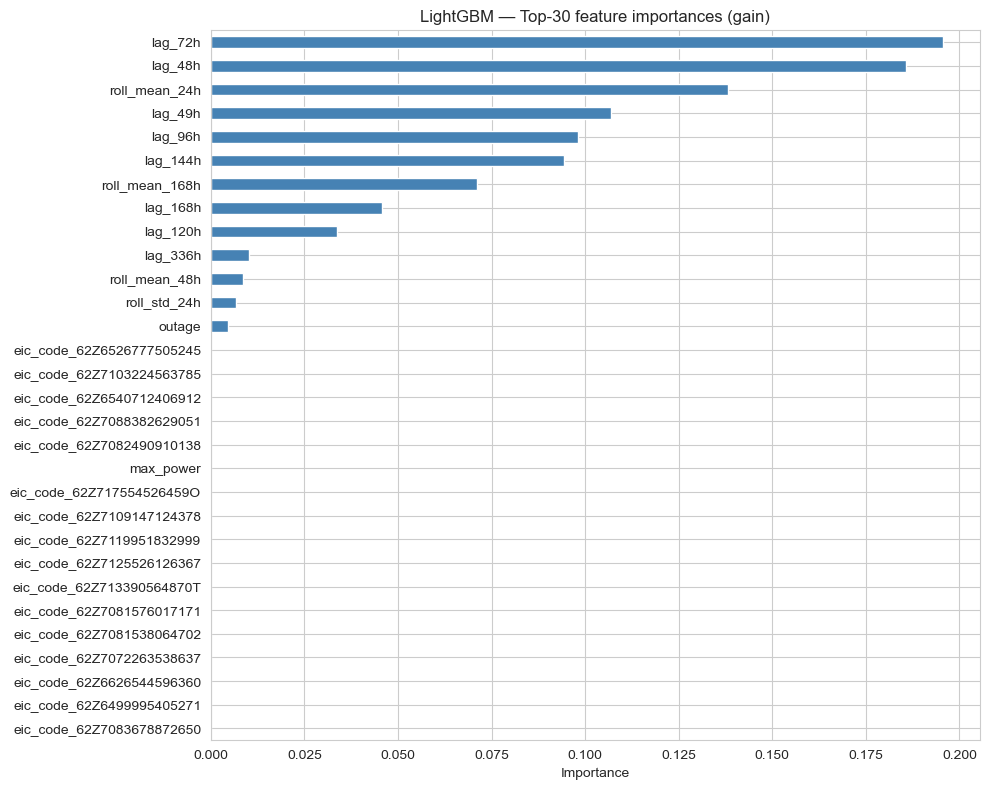

In [26]:
import matplotlib.pyplot as plt

fi = pd.Series(
    final_model_outages.feature_importances_,
    index=train.drop(columns=[Y_COL, 'datetime']).columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(30).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("LightGBM — Top-30 feature importances (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

# NO Blackouts

In [16]:
best_params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",        # or "gpu_hist" if using GPU
    "device": DEVICE,             # "cpu" or "cuda"
    "n_jobs": N_JOBS,
    "random_state": 42,
    "max_bin": 256,
    "max_depth": 3,
    "learning_rate": 0.0016354007723455718,
    "n_estimators": 821,
    "min_child_weight": 1.1364071733780492,
    "subsample": 0.9965203710884993,
    "colsample_bytree": 0.9093100019446257,
    "gamma": 1.9085233994035078,
    "reg_alpha": 1.1783105320188792e-05,
    "reg_lambda": 0.0006212878581984038
}

mlflow.set_experiment("xgboost_without_blackouts")
mlflow.xgboost.autolog(log_models=False, silent=True)

with mlflow.start_run():
    mlflow.log_params(best_params)

    print("Training final XGBoost model …")

    final_model = xgb.XGBRegressor(**best_params)

    final_model.fit(
        X_train.drop(columns=['datetime', 'outage']),
        y_train,
        eval_set=[(X_val.drop(columns=['datetime', 'outage']), y_val)],
        verbose=50,
        # early_stopping_rounds=50,
    )
print("Training complete.")

2026/04/28 18:33:09 INFO mlflow.tracking.fluent: Experiment with name 'xgboost_without_blackouts' does not exist. Creating a new experiment.


Training final XGBoost model …
[0]	validation_0-rmse:17.66125
[50]	validation_0-rmse:16.60828
[100]	validation_0-rmse:15.64617
[150]	validation_0-rmse:14.76691
[200]	validation_0-rmse:13.96776
[250]	validation_0-rmse:13.23632
[300]	validation_0-rmse:12.56544
[350]	validation_0-rmse:11.95351
[400]	validation_0-rmse:11.39850
[450]	validation_0-rmse:10.89619
[500]	validation_0-rmse:10.43843
[550]	validation_0-rmse:10.02303
[600]	validation_0-rmse:9.64629
[650]	validation_0-rmse:9.30547
[700]	validation_0-rmse:9.00065
[750]	validation_0-rmse:8.72583
[800]	validation_0-rmse:8.48002
[820]	validation_0-rmse:8.38914
Training complete.


In [17]:
print("Predicting validation set …")
val_preds = final_model.predict(X_val.drop(columns=['datetime', 'outage'])).clip(min=0)
val_eval = val.copy()
val_eval["pred"] = val_preds
val_eval = val_eval.dropna(subset=[Y_COL]).copy()
print(f"Val predictions complete — {len(val_eval):,} rows")

Predicting validation set …
Val predictions complete — 293,880 rows


In [18]:
print("Predicting test set …")
test_preds = final_model.predict(X_test.drop(columns=['datetime', 'outage'])).clip(min=0)
test_eval = test.copy()
test_eval["pred"] = test_preds
test_eval = test_eval.dropna(subset=[Y_COL]).copy()
print(f"Test predictions complete — {len(test_eval):,} rows")

Predicting test set …
Test predictions complete — 295,430 rows


In [19]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

mlflow.log_metrics({
    "val_smape":      val_smape_v,
    "val_rmse":       val_rmse_v,
    "val_mape":       val_mape_v,
    "val_money":      val_money_v,
    "val_money_pct":  val_money_pct_v,
    "test_smape":     test_smape_v,
    "test_rmse":      test_rmse_v,
    "test_mape":      test_mape_v,
    "test_money":     test_money_v,
    "test_money_pct": test_money_pct_v,
})
mlflow.end_run()
print(f"MLflow run logged → {mlflow.get_tracking_uri()}")

── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
SMAPE     : 21.5612
RMSE      : 8.3891
MAPE      : 75.09 %
MONEY     : 2028384.4094
MONEY_PCT : 6.9383%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 22.1948
RMSE      : 9.2841
MAPE      : 103.02 %
MONEY     : 2403626.3487
MONEY_PCT : 8.1336%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [33]:
X_val.columns.tolist()

['datetime',
 'max_power',
 'max_solar',
 'max_ev',
 'latitude',
 'longitude',
 'temperature_2m',
 'relative_humidity_2m',
 'dew_point_2m',
 'apparent_temperature',
 'surface_pressure',
 'cloud_cover',
 'cloud_cover_low',
 'cloud_cover_mid',
 'cloud_cover_high',
 'wind_speed_10m',
 'wind_direction_10m',
 'wind_gusts_10m',
 'shortwave_radiation',
 'direct_normal_irradiance',
 'diffuse_radiation',
 'precipitation',
 'rain',
 'snowfall',
 'time_idx',
 'sell_bm_price',
 'buy_bm_price',
 'dam_price',
 'lag_48h',
 'lag_49h',
 'lag_50h',
 'lag_51h',
 'lag_52h',
 'lag_72h',
 'lag_96h',
 'lag_120h',
 'lag_144h',
 'lag_168h',
 'lag_336h',
 'roll_mean_24h',
 'roll_std_24h',
 'roll_mean_48h',
 'roll_std_48h',
 'roll_mean_168h',
 'roll_std_168h',
 'diff_24h',
 'diff_168h',
 'outage',
 'dso_desc_Волинь',
 'dso_desc_Вінниця',
 'dso_desc_Дніпро',
 'dso_desc_Житомир',
 'dso_desc_Запоріжжя',
 'dso_desc_Київ',
 'dso_desc_КиївОбл',
 'dso_desc_Кропивницький',
 'dso_desc_Львів',
 'dso_desc_Миколаїв',
 'dso_

In [ ]:
── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
SMAPE     : 21.5611
RMSE      : 8.3960
MAPE      : 74.98 %
MONEY     : 2028141.9970
MONEY_PCT : 6.9375%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 22.1945
RMSE      : 9.2948
MAPE      : 102.87 %
MONEY     : 2402420.0238
MONEY_PCT : 8.1295%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns

── Validation ──────────────────────────────────────────────
Aligned samples : 293,880
SMAPE     : 21.5612
RMSE      : 8.3891
MAPE      : 75.09 %
MONEY     : 2028384.4094
MONEY_PCT : 6.9383%
── Test ────────────────────────────────────────────────────
Aligned samples : 295,430
SMAPE     : 22.1948
RMSE      : 9.2841
MAPE      : 103.02 %
MONEY     : 2403626.3487
MONEY_PCT : 8.1336%
MLflow run logged → file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


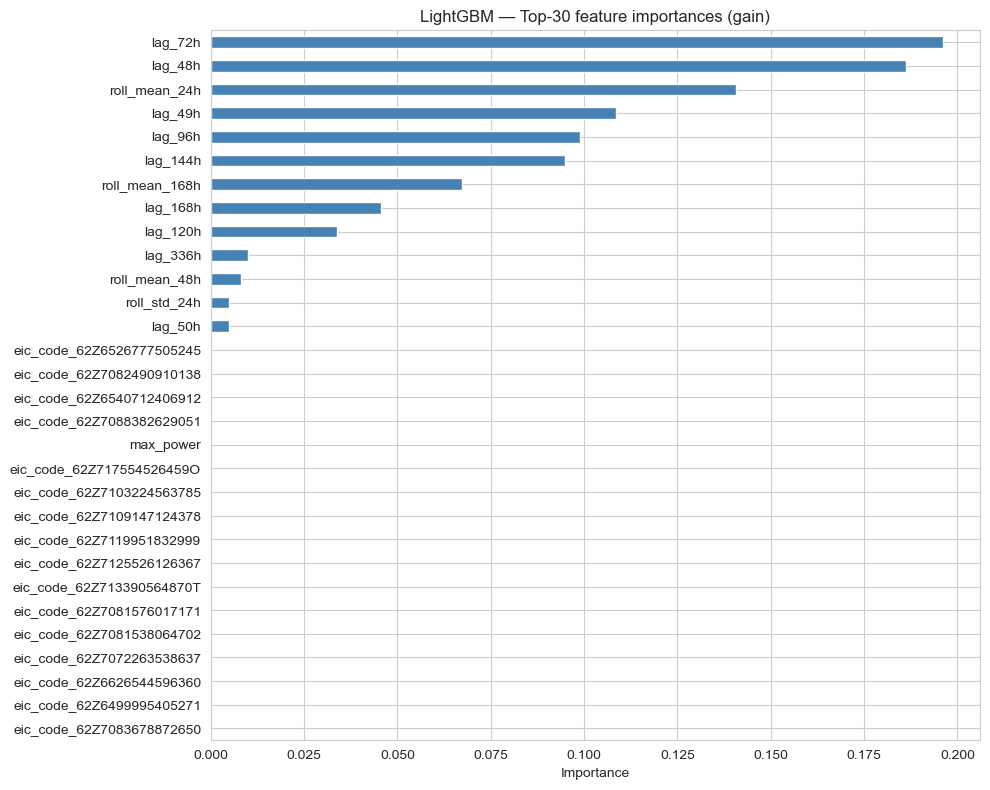

In [27]:
import matplotlib.pyplot as plt

fi = pd.Series(
    final_model.feature_importances_,
    index=train.drop(columns=[Y_COL, 'datetime', 'outage']).columns,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(30).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("LightGBM — Top-30 feature importances (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## Forecast visualisation

In [20]:
import matplotlib.dates as mdates


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EIC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} – {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

In [30]:
final_model.save_model("../models/xgb/xgb_model.json")

In [ ]:
plot_forecast(test_eval, eic_code='62Z2410378897684')